## Daily Forecast

LOADING AND PREPARING DATA...
Loading data from: ../data/processed/daily_item_sales.csv
Data shape: (20389, 3)
Date range: 2022-01-01 00:00:00 to 2026-03-31 00:00:00
Number of items: 44

CREATING FEATURES...
Features created. Shape: (20389, 37)

TRAINING WITH CROSS-VALIDATION...

FOLD 1: Testing 2025-06-01 to 2025-06-30
Training: 2022-01-01 → 2025-05-31 (14756 days)
Testing : 2025-06-01 → 2025-06-30 (568 days)
Fold 1 Results:
  R²: 0.9471
  wMAPE: 4.53%
  MAE: 0.10

FOLD 2: Testing 2025-07-01 to 2025-07-31
Training: 2022-01-01 → 2025-06-30 (15324 days)
Testing : 2025-07-01 → 2025-07-31 (653 days)
Fold 2 Results:
  R²: 0.8935
  wMAPE: 6.99%
  MAE: 0.15

FOLD 3: Testing 2025-08-01 to 2025-08-31
Training: 2022-01-01 → 2025-07-31 (15977 days)
Testing : 2025-08-01 → 2025-08-31 (562 days)
Fold 3 Results:
  R²: 0.9107
  wMAPE: 6.42%
  MAE: 0.13

CROSS-VALIDATION SUMMARY
   fold        r2     wmape       mae  test_days
0     1  0.947122  4.527082  0.098592        568
1     2  0.893535  6.99351

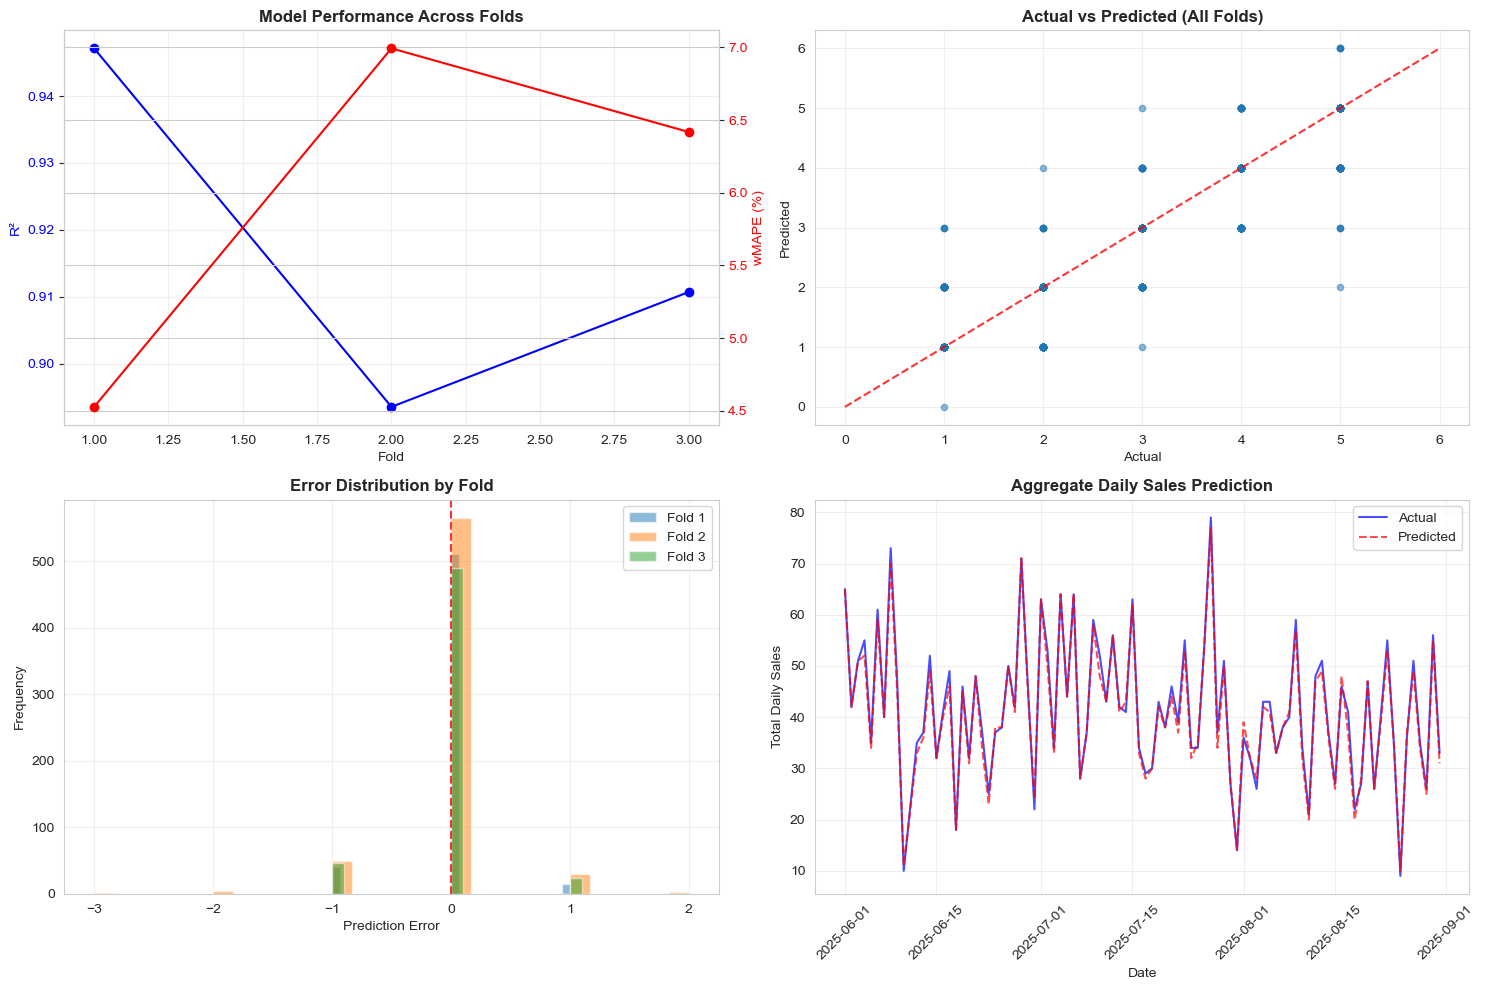


ANALYSIS COMPLETE!
LOADING AND PREPARING DATA...
Loading data from: ../data/processed/daily_item_sales.csv
Data shape: (20389, 3)
Date range: 2022-01-01 00:00:00 to 2026-03-31 00:00:00
Number of items: 44

CREATING FEATURES...
Features created. Shape: (20389, 37)

TRAINING WITH CROSS-VALIDATION...

FOLD 1: Testing 2025-06-01 to 2025-06-30
Training: 2022-01-01 → 2025-05-31 (14756 days)
Testing : 2025-06-01 → 2025-06-30 (568 days)
Fold 1 Results:
  R²: 0.9471
  wMAPE: 4.53%
  MAE: 0.10

FOLD 2: Testing 2025-07-01 to 2025-07-31
Training: 2022-01-01 → 2025-06-30 (15324 days)
Testing : 2025-07-01 → 2025-07-31 (653 days)
Fold 2 Results:
  R²: 0.8935
  wMAPE: 6.99%
  MAE: 0.15

FOLD 3: Testing 2025-08-01 to 2025-08-31
Training: 2022-01-01 → 2025-07-31 (15977 days)
Testing : 2025-08-01 → 2025-08-31 (562 days)
Fold 3 Results:
  R²: 0.9107
  wMAPE: 6.42%
  MAE: 0.13

CROSS-VALIDATION SUMMARY
   fold        r2     wmape       mae  test_days
0     1  0.947122  4.527082  0.098592        568
1     

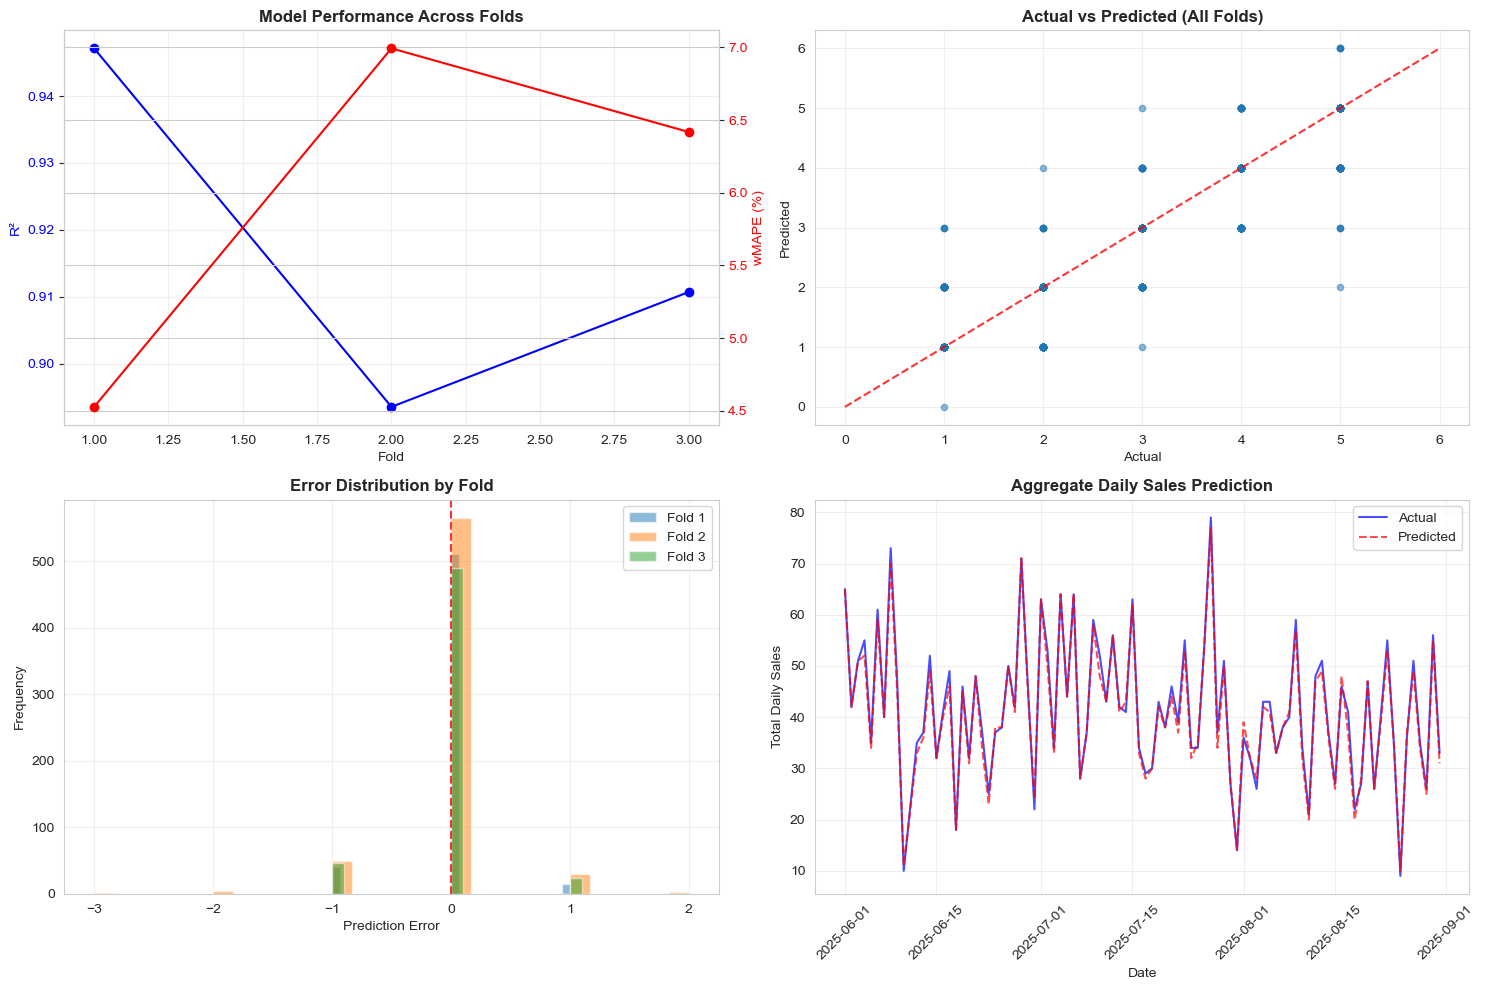


TRAINING FINAL MODELS ON ALL DATA...

GENERATING 3-MONTH FORECAST...
Latest date in dataset: 2026-03-31
Forecasting for Air Mineral...
Forecasting for Air mineral...
Forecasting for Anindita Honey Butter...
Forecasting for Arunika...
Forecasting for Basreng...
Forecasting for Black Hot...
Forecasting for Black Ice...
Forecasting for Candana Vanilla...
Forecasting for Cappucino Hot...
Forecasting for Cappucino Ice...
Forecasting for Cireng...
Forecasting for Donat...
Forecasting for Espresso...
Forecasting for Kasmaran...
Forecasting for Kenang...
Forecasting for Kinasih...
Forecasting for Kirana...
Forecasting for Kirana Strawberry...
Forecasting for Latte Hot...
Forecasting for Latte Ice...
Forecasting for Lychee Tea Hot...
Forecasting for Lychee Tea Ice...
Forecasting for Magic...
Forecasting for Matcha Hot...
Forecasting for Matcha Ice...
Forecasting for Mie Goreng...
Forecasting for Mie Rebus...
Forecasting for Nasi Gila...
Forecasting for Nasi Goreng Jawa...
Forecasting for Nasi 

In [6]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD & KEEP DAILY DATA
# ==========================================
def load_and_prep_data(filepath):
    print(f"Loading data from: {filepath}")
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[~df['Item'].str.strip().str.lower().str.startswith('add')]
    df_daily = df.sort_values(['Item', 'Date']).reset_index(drop=True)
    return df_daily

# ==========================================
# 2. CALENDAR & REBRANDING FEATURES
# ==========================================
def add_calendar_features(df):
    data = df.copy()
    data = data.sort_values('Date').reset_index(drop=True)

    data['Month'] = data['Date'].dt.month
    data['Week'] = data['Date'].dt.isocalendar().week.astype(int)
    data['Year'] = data['Date'].dt.year
    data['DOY'] = data['Date'].dt.dayofyear
    data['DOW'] = data['Date'].dt.weekday
    data['Quarter'] = data['Date'].dt.quarter
    data['Is_Weekend'] = (data['DOW'] >= 5).astype(int)

    # Seasonality features
    data['Sin_Week'] = np.sin(2 * np.pi * data['Week'] / 52)
    data['Cos_Week'] = np.cos(2 * np.pi * data['Week'] / 52)
    data['Sin_Month'] = np.sin(2 * np.pi * data['Month'] / 12)
    data['Cos_Month'] = np.cos(2 * np.pi * data['Month'] / 12)
    
    # Trend
    data['Days_Since_Start'] = (data['Date'] - data['Date'].min()).dt.days
    data['Day_Of_Month'] = data['Date'].dt.day

    # Payday features
    data['Is_Payday'] = ((data['Date'].dt.day <= 7) | (data['Date'].dt.day >= 25)).astype(int)
    data['Is_Weekend_Before_Payday'] = ((data['DOW'] >= 4) & (data['Date'].dt.day >= 25)).astype(int)

    # Holiday features
    holidays = [
        '2024-01-01','2024-04-10','2024-04-11','2024-04-12','2024-05-01','2024-05-23',
        '2024-06-01','2024-06-17','2024-12-25',
        '2025-01-01','2025-03-01','2025-03-30','2025-03-31','2025-05-01','2025-05-12',
        '2025-06-01','2025-06-07','2025-12-25',
        '2026-01-01','2026-02-17','2026-03-09','2026-05-01','2026-05-21','2026-12-25'
    ]
    data['Is_Holiday'] = data['Date'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)
    data['Is_Near_Holiday'] = data['Date'].apply(
        lambda x: any(abs((x - pd.to_datetime(h)).days) <= 3 for h in holidays)
    ).astype(int)

    # Ramadan
    data['Is_Ramadan'] = 0
    for year in [2024, 2025, 2026]:
        mask = (data['Date'] >= f'{year}-02-28') & (data['Date'] <= f'{year}-04-10')
        data.loc[mask, 'Is_Ramadan'] = 1

    # Rebranding
    data['Is_Post_Rebranding'] = (data['Date'] >= '2025-05-01').astype(int)
    data['Days_Since_Rebrand'] = ((data['Date'] - pd.to_datetime('2025-05-01')).dt.days).clip(lower=0)

    return data

# ==========================================
# 3. FEATURE ENGINEERING (MORE CONSERVATIVE)
# ==========================================
def create_features(df):
    data = add_calendar_features(df)
    data = data.sort_values(['Item', 'Date'])
    data['Item_Code'] = data['Item'].astype('category').cat.codes

    for item in data['Item'].unique():
        mask = data['Item'] == item
        g = data.loc[mask, 'Quantity_Sold']

        # More conservative lags (avoid look-ahead bias)
        data.loc[mask, 'Lag_1'] = g.shift(1)
        data.loc[mask, 'Lag_7'] = g.shift(7)
        data.loc[mask, 'Lag_14'] = g.shift(14)

        # Rolling statistics with more periods for stability
        shifted = g.shift(1)
        data.loc[mask, 'Roll_Mean_7']  = shifted.rolling(7, min_periods=1).mean()
        data.loc[mask, 'Roll_Mean_14']  = shifted.rolling(14, min_periods=1).mean()
        data.loc[mask, 'Roll_Std_7']   = shifted.rolling(7, min_periods=1).std().fillna(0)

        # EWMA
        data.loc[mask, 'EWMA_7']  = shifted.ewm(span=7, adjust=False).mean()

        # Momentum
        data.loc[mask, 'Diff_1']  = g.diff(1)
        data.loc[mask, 'Diff_7']  = g.diff(7)

        # Black Ice handling (more conservative)
        if item == 'Black Ice':
            pre_mask = data.loc[mask, 'Date'] < '2025-05-01'
            post_mask = data.loc[mask, 'Date'] >= '2025-05-01'
            
            if pre_mask.any() and post_mask.any():
                pre_mean = data.loc[mask & pre_mask, 'Quantity_Sold'].mean()
                post_mean = data.loc[mask & post_mask, 'Quantity_Sold'].mean()
                
                surge_factor = min(post_mean / (pre_mean + 1), 3.0)  # Reduced from 5x to 3x
                
                days_since = data.loc[mask & post_mask, 'Days_Since_Rebrand']
                decay_factor = np.maximum(0.3, 1 - days_since / 140)  # Slower decay
                
                data.loc[mask & post_mask, 'Black_Ice_Surge'] = surge_factor * decay_factor
                data.loc[mask & pre_mask, 'Black_Ice_Surge'] = 1.0
            else:
                data.loc[mask, 'Black_Ice_Surge'] = 1.0
        else:
            data.loc[mask, 'Black_Ice_Surge'] = 1.0

        # Rebranding effect for other items
        pre_mean  = g[data.loc[mask, 'Date'] < '2025-05-01'].mean()
        post_mean = g[data.loc[mask, 'Date'] >= '2025-05-01'].mean()
        surge = min(post_mean / (pre_mean + 1), 2.0) if pd.notna(post_mean) else 1.0  # Reduced from 3x to 2x
        data.loc[mask, 'Rebrand_Surge'] = surge

    # Interaction features
    data['Payday_Weekend'] = data['Is_Payday'] * data['Is_Weekend']
    data['Holiday_Weekend'] = data['Is_Holiday'] * data['Is_Weekend']
    
    data = data.fillna(0)
    data.replace([np.inf, -np.inf], 0, inplace=True)
    
    # Less aggressive clipping
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in ['Date', 'Item_Code']:
            data[col] = data[col].clip(
                lower=data[col].quantile(0.05),
                upper=data[col].quantile(0.95)
            )
    
    return data

# ==========================================
# 4. ROBUST TRAINING WITH CROSS-VALIDATION
# ==========================================
def train_with_cv(df_features):
    # Use multiple test periods for robust evaluation
    test_periods = [
        ('2025-06-01', '2025-06-30'),  # 1 month
        ('2025-07-01', '2025-07-31'),  # 1 month
        ('2025-08-01', '2025-08-31'),  # 1 month
    ]
    
    all_predictions = []
    cv_scores = []
    
    features = [
        'Item_Code','Month','Week','Year','DOY','DOW','Quarter','Is_Weekend','Sin_Week','Cos_Week',
        'Sin_Month','Cos_Month','Days_Since_Start','Day_Of_Month','Is_Payday',
        'Is_Weekend_Before_Payday','Is_Holiday','Is_Near_Holiday','Is_Ramadan',
        'Is_Post_Rebranding','Days_Since_Rebrand','Black_Ice_Surge','Rebrand_Surge',
        'Lag_1','Lag_7','Lag_14','Roll_Mean_7','Roll_Mean_14','Roll_Std_7','EWMA_7',
        'Diff_1','Diff_7','Payday_Weekend','Holiday_Weekend'
    ]
    
    for i, (test_start, test_end) in enumerate(test_periods):
        print(f"\n{'='*50}")
        print(f"FOLD {i+1}: Testing {test_start} to {test_end}")
        print(f"{'='*50}")
        
        train = df_features[df_features['Date'] < test_start].copy()
        test  = df_features[(df_features['Date'] >= test_start) & (df_features['Date'] <= test_end)].copy()
        
        print(f"Training: {train['Date'].min().date()} → {train['Date'].max().date()} ({len(train)} days)")
        print(f"Testing : {test['Date'].min().date()} → {test['Date'].max().date()} ({len(test)} days)")
        
        # More conservative model parameters
        global_model = XGBRegressor(
            objective='reg:squarederror',
            n_estimators=500,  # Reduced from 1000
            learning_rate=0.1,   # Increased from 0.05 for faster learning
            max_depth=4,         # Reduced from 6
            subsample=0.8, 
            colsample_bytree=0.8,
            min_child_weight=5,  # Increased for more regularization
            gamma=0.1,           # Added regularization
            n_jobs=-1, 
            random_state=42
        )
        
        global_model.fit(train[features], train['Quantity_Sold'])
        
        fold_predictions = []
        for item in test['Item'].unique():
            train_item = train[train['Item'] == item]
            test_item  = test[test['Item'] == item].copy()

            if len(train_item) >= 30:  # Reduced minimum requirement
                model = XGBRegressor(
                    objective='reg:squarederror',
                    n_estimators=500,
                    learning_rate=0.1,
                    max_depth=4,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=5,
                    gamma=0.1,
                    n_jobs=-1,
                    random_state=42
                )
                
                model.fit(train_item[features], train_item['Quantity_Sold'], verbose=False)
                pred = model.predict(test_item[features])
            else:
                pred = global_model.predict(test_item[features])

            # Conservative bounds
            pred = np.maximum(0, pred)
            pred = np.minimum(pred, train_item['Quantity_Sold'].max() * 2)  # Reduced from 3x
            
            test_item['Predicted'] = pred.round(0)
            test_item['Fold'] = i + 1
            fold_predictions.append(test_item)
        
        fold_results = pd.concat(fold_predictions)
        
        # Calculate fold metrics
        fold_r2 = r2_score(fold_results['Quantity_Sold'], fold_results['Predicted'])
        fold_wmape = 100 * abs(fold_results['Quantity_Sold'] - fold_results['Predicted']).sum() / fold_results['Quantity_Sold'].sum()
        fold_mae = mean_absolute_error(fold_results['Quantity_Sold'], fold_results['Predicted'])
        
        cv_scores.append({
            'fold': i + 1,
            'r2': fold_r2,
            'wmape': fold_wmape,
            'mae': fold_mae,
            'test_days': len(test)
        })
        
        print(f"Fold {i+1} Results:")
        print(f"  R²: {fold_r2:.4f}")
        print(f"  wMAPE: {fold_wmape:.2f}%")
        print(f"  MAE: {fold_mae:.2f}")
        
        all_predictions.append(fold_results)
    
    # Combine all predictions
    final_predictions = pd.concat(all_predictions).sort_values(['Item', 'Date'])
    
    # Print CV summary
    print(f"\n{'='*50}")
    print("CROSS-VALIDATION SUMMARY")
    print(f"{'='*50}")
    
    cv_df = pd.DataFrame(cv_scores)
    print(cv_df)
    
    print(f"\nAverage Performance Across Folds:")
    print(f"  R²: {cv_df['r2'].mean():.4f} ± {cv_df['r2'].std():.4f}")
    print(f"  wMAPE: {cv_df['wmape'].mean():.2f}% ± {cv_df['wmape'].std():.2f}%")
    print(f"  MAE: {cv_df['mae'].mean():.2f} ± {cv_df['mae'].std():.2f}")
    
    return final_predictions, cv_df

# ==========================================
# 5. OVERFITTING DIAGNOSTICS
# ==========================================
def check_overfitting(cv_scores):
    print(f"\n{'='*50}")
    print("OVERFITTING DIAGNOSTICS")
    print(f"{'='*50}")
    
    cv_df = pd.DataFrame(cv_scores)
    
    # Check variance in performance
    r2_var = cv_df['r2'].var()
    wmape_var = cv_df['wmape'].var()
    
    print(f"Performance Variance Across Folds:")
    print(f"  R² Variance: {r2_var:.6f}")
    print(f"  wMAPE Variance: {wmape_var:.2f}")
    
    if r2_var > 0.01 or wmape_var > 5:
        print("⚠️  HIGH VARIANCE DETECTED - Model may be overfitting!")
    else:
        print("✅ Stable performance across folds")
    
    # Check for degradation
    r2_trend = cv_df['r2'].iloc[-1] - cv_df['r2'].iloc[0]
    wmape_trend = cv_df['wmape'].iloc[-1] - cv_df['wmape'].iloc[0]
    
    print(f"\nPerformance Trend (Last - First Fold):")
    print(f"  R² Change: {r2_trend:+.4f}")
    print(f"  wMAPE Change: {wmape_trend:+.2f}%")
    
    if r2_trend < -0.05 or wmape_trend > 2:
        print("⚠️  PERFORMANCE DEGRADATION - Model may not generalize well!")
    else:
        print("✅ Consistent performance over time")

# ==========================================
# 6. VISUALIZATION WITH OVERFITTING CHECKS
# ==========================================
def visualize_with_overfitting_check(predictions, cv_scores):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Performance across folds
    cv_df = pd.DataFrame(cv_scores)
    ax1 = axes[0, 0]
    ax1.plot(cv_df['fold'], cv_df['r2'], 'bo-', label='R²')
    ax1.set_xlabel('Fold')
    ax1.set_ylabel('R²', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_title('Model Performance Across Folds', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(cv_df['fold'], cv_df['wmape'], 'ro-', label='wMAPE')
    ax1_twin.set_ylabel('wMAPE (%)', color='r')
    ax1_twin.tick_params(axis='y', labelcolor='r')
    
    # 2. Prediction vs Actual (all folds)
    ax2 = axes[0, 1]
    ax2.scatter(predictions['Quantity_Sold'], predictions['Predicted'], alpha=0.5, s=20)
    max_val = max(predictions['Quantity_Sold'].max(), predictions['Predicted'].max())
    ax2.plot([0, max_val], [0, max_val], 'r--', alpha=0.8)
    ax2.set_xlabel('Actual')
    ax2.set_ylabel('Predicted')
    ax2.set_title('Actual vs Predicted (All Folds)', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # 3. Error distribution by fold
    ax3 = axes[1, 0]
    for fold in predictions['Fold'].unique():
        fold_data = predictions[predictions['Fold'] == fold]
        errors = fold_data['Predicted'] - fold_data['Quantity_Sold']
        ax3.hist(errors, bins=30, alpha=0.5, label=f'Fold {fold}')
    ax3.axvline(x=0, color='red', linestyle='--', alpha=0.8)
    ax3.set_xlabel('Prediction Error')
    ax3.set_ylabel('Frequency')
    ax3.set_title('Error Distribution by Fold', fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Time series of predictions
    ax4 = axes[1, 1]
    daily_agg = predictions.groupby('Date')[['Quantity_Sold', 'Predicted']].sum()
    ax4.plot(daily_agg.index, daily_agg['Quantity_Sold'], 'b-', label='Actual', alpha=0.7)
    ax4.plot(daily_agg.index, daily_agg['Predicted'], 'r--', label='Predicted', alpha=0.7)
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Total Daily Sales')
    ax4.set_title('Aggregate Daily Sales Prediction', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 7. RUN WITH OVERFITTING CHECKS
# ==========================================

print("LOADING AND PREPARING DATA...")
df_raw = load_and_prep_data('../data/processed/daily_item_sales.csv')
print(f"Data shape: {df_raw.shape}")
print(f"Date range: {df_raw['Date'].min()} to {df_raw['Date'].max()}")
print(f"Number of items: {df_raw['Item'].nunique()}")

print("\nCREATING FEATURES...")
df_feat = create_features(df_raw)
print(f"Features created. Shape: {df_feat.shape}")

print("\nTRAINING WITH CROSS-VALIDATION...")
predictions, cv_scores = train_with_cv(df_feat)

print("\nCHECKING FOR OVERFITTING...")
check_overfitting(cv_scores)

print("\nGENERATING VISUALIZATIONS...")
visualize_with_overfitting_check(predictions, cv_scores)

print("\n" + "="*50)
print("ANALYSIS COMPLETE!")
print("="*50)

# ==========================================
# 8. FORECAST 3 MONTHS AHEAD
# ==========================================
def forecast_3_months_ahead(df_features, model, global_model, features):
    """
    Generate 3-month ahead forecasts for all items
    
    Parameters:
    - df_features: DataFrame with historical data and features
    - model: Trained XGBoost model (will be retrained on all data)
    - global_model: Global XGBoost model
    - features: List of feature columns
    
    Returns:
    - DataFrame with forecasts for the next 3 months
    """
    print("\nGENERATING 3-MONTH FORECAST...")
    
    # Get the latest date in the dataset
    latest_date = df_features['Date'].max()
    print(f"Latest date in dataset: {latest_date.date()}")
    
    # Create a date range for the next 3 months
    forecast_dates = pd.date_range(
        start=latest_date + pd.Timedelta(days=1),
        end=latest_date + pd.Timedelta(days=90),
        freq='D'
    )
    
    # Get all unique items
    items = df_features['Item'].unique()
    
    # Create an empty DataFrame to store forecasts
    forecasts = []
    
    # For each item, generate forecasts
    for item in items:
        print(f"Forecasting for {item}...")
        
        # Get historical data for this item
        item_data = df_features[df_features['Item'] == item].copy()
        
        # Retrain the model on all available data for this item
        if len(item_data) >= 30:
            item_model = XGBRegressor(
                objective='reg:squarederror',
                n_estimators=500,
                learning_rate=0.1,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=5,
                gamma=0.1,
                n_jobs=-1,
                random_state=42
            )
            item_model.fit(item_data[features], item_data['Quantity_Sold'], verbose=False)
        else:
            item_model = global_model
        
        # Create a DataFrame to store the forecast for this item
        item_forecast = pd.DataFrame({
            'Date': forecast_dates,
            'Item': item
        })
        
        # Initialize with the last known values
        last_known = item_data.iloc[-1].copy()
        
        # Iteratively forecast each day
        for i, date in enumerate(forecast_dates):
            # Create features for this date
            date_features = pd.DataFrame({'Date': [date]})
            
            # Add calendar features
            date_features = add_calendar_features(date_features)
            
            # Add item code
            date_features['Item_Code'] = last_known['Item_Code']
            
            # For lag features, use historical values when available, then use forecasts
            if i == 0:
                # First day: use historical values
                date_features['Lag_1'] = last_known['Quantity_Sold']
                
                # For longer lags, get from historical data
                if len(item_data) >= 7:
                    date_features['Lag_7'] = item_data.iloc[-7]['Quantity_Sold']
                else:
                    date_features['Lag_7'] = last_known['Quantity_Sold']
                
                if len(item_data) >= 14:
                    date_features['Lag_14'] = item_data.iloc[-14]['Quantity_Sold']
                else:
                    date_features['Lag_14'] = last_known['Quantity_Sold']
                
                # Rolling features
                date_features['Roll_Mean_7'] = item_data['Quantity_Sold'].tail(7).mean()
                date_features['Roll_Mean_14'] = item_data['Quantity_Sold'].tail(14).mean()
                date_features['Roll_Std_7'] = item_data['Quantity_Sold'].tail(7).std()
                date_features['EWMA_7'] = item_data['Quantity_Sold'].ewm(span=7).mean().iloc[-1]
                
                # Diff features
                date_features['Diff_1'] = last_known['Quantity_Sold'] - item_data.iloc[-2]['Quantity_Sold'] if len(item_data) > 1 else 0
                date_features['Diff_7'] = last_known['Quantity_Sold'] - (item_data.iloc[-8]['Quantity_Sold'] if len(item_data) > 7 else last_known['Quantity_Sold'])
            else:
                # Subsequent days: use our own forecasts
                date_features['Lag_1'] = forecasts[-1]['Quantity_Sold'] if forecasts[-1]['Item'] == item else 0
                
                # For longer lags, get from forecasts if available
                if i >= 7:
                    lag_7 = [f['Quantity_Sold'] for f in forecasts if f['Item'] == item and f['Date'] == date - pd.Timedelta(days=7)]
                    date_features['Lag_7'] = lag_7[0] if lag_7 else 0
                else:
                    # Use historical data if available
                    hist_lag_7 = item_data[item_data['Date'] == date - pd.Timedelta(days=7)]
                    date_features['Lag_7'] = hist_lag_7['Quantity_Sold'].iloc[0] if len(hist_lag_7) > 0 else 0
                
                if i >= 14:
                    lag_14 = [f['Quantity_Sold'] for f in forecasts if f['Item'] == item and f['Date'] == date - pd.Timedelta(days=14)]
                    date_features['Lag_14'] = lag_14[0] if lag_14 else 0
                else:
                    # Use historical data if available
                    hist_lag_14 = item_data[item_data['Date'] == date - pd.Timedelta(days=14)]
                    date_features['Lag_14'] = hist_lag_14['Quantity_Sold'].iloc[0] if len(hist_lag_14) > 0 else 0
                
                # Rolling features - combine historical and forecasted data
                recent_values = []
                
                # Get last 7 days of actuals and forecasts
                for d in range(1, 8):
                    check_date = date - pd.Timedelta(days=d)
                    hist_data = item_data[item_data['Date'] == check_date]
                    if len(hist_data) > 0:
                        recent_values.append(hist_data['Quantity_Sold'].iloc[0])
                    else:
                        # Look in forecasts
                        forecast_val = [f['Quantity_Sold'] for f in forecasts if f['Item'] == item and f['Date'] == check_date]
                        if forecast_val:
                            recent_values.append(forecast_val[0])
                        else:
                            recent_values.append(0)
                
                date_features['Roll_Mean_7'] = np.mean(recent_values)
                date_features['Roll_Std_7'] = np.std(recent_values)
                
                # For 14-day rolling, we'd need more data, but we'll simplify
                date_features['Roll_Mean_14'] = date_features['Roll_Mean_7']  # Simplification
                
                # EWMA - simplified approach
                date_features['EWMA_7'] = date_features['Roll_Mean_7']
                
                # Diff features
                date_features['Diff_1'] = date_features['Lag_1'] - (forecasts[-2]['Quantity_Sold'] if len(forecasts) > 1 and forecasts[-2]['Item'] == item else last_known['Quantity_Sold'])
                date_features['Diff_7'] = date_features['Lag_1'] - date_features['Lag_7']
            
            # Black Ice and Rebranding features
            if item == 'Black Ice':
                if date >= pd.to_datetime('2025-05-01'):
                    days_since = (date - pd.to_datetime('2025-05-01')).days
                    pre_mean = item_data[item_data['Date'] < '2025-05-01']['Quantity_Sold'].mean()
                    post_mean = item_data[item_data['Date'] >= '2025-05-01']['Quantity_Sold'].mean()
                    surge_factor = min(post_mean / (pre_mean + 1), 3.0) if pd.notna(pre_mean) and pd.notna(post_mean) else 1.0
                    decay_factor = np.maximum(0.3, 1 - days_since / 140)
                    date_features['Black_Ice_Surge'] = surge_factor * decay_factor
                else:
                    date_features['Black_Ice_Surge'] = 1.0
            else:
                date_features['Black_Ice_Surge'] = 1.0
            
            # Rebranding surge
            if date >= pd.to_datetime('2025-05-01'):
                pre_mean = item_data[item_data['Date'] < '2025-05-01']['Quantity_Sold'].mean()
                post_mean = item_data[item_data['Date'] >= '2025-05-01']['Quantity_Sold'].mean()
                surge = min(post_mean / (pre_mean + 1), 2.0) if pd.notna(pre_mean) and pd.notna(post_mean) else 1.0
                date_features['Rebrand_Surge'] = surge
            else:
                date_features['Rebrand_Surge'] = 1.0
            
            # Interaction features
            date_features['Payday_Weekend'] = date_features['Is_Payday'] * date_features['Is_Weekend']
            date_features['Holiday_Weekend'] = date_features['Is_Holiday'] * date_features['Is_Weekend']
            
            # Ensure all required features are present
            for feature in features:
                if feature not in date_features.columns:
                    date_features[feature] = 0
            
            # Make prediction
            prediction = item_model.predict(date_features[features])[0]
            
            # Apply bounds
            prediction = max(0, prediction)
            prediction = min(prediction, item_data['Quantity_Sold'].max() * 2)
            
            # Round to nearest integer
            prediction = round(prediction)
            
            # Add to forecasts
            forecasts.append({
                'Date': date,
                'Item': item,
                'Quantity_Sold': prediction
            })
    
    # Convert to DataFrame
    forecast_df = pd.DataFrame(forecasts)
    
    print(f"Generated {len(forecast_df)} forecast records for {len(items)} items")
    return forecast_df

# Add this function to visualize the forecasts
def visualize_forecasts(historical_data, forecast_data):
    """
    Visualize the historical data and forecasts
    
    Parameters:
    - historical_data: DataFrame with historical sales data
    - forecast_data: DataFrame with forecast data
    """
    print("\nGENERATING FORECAST VISUALIZATIONS...")
    
    # Get all unique items
    items = historical_data['Item'].unique()
    
    # Create a figure with subplots for each item
    n_items = len(items)
    n_cols = 2
    n_rows = (n_items + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_items == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Flatten axes for easier iteration
    axes = axes.flatten()
    
    for i, item in enumerate(items):
        ax = axes[i]
        
        # Get historical data for this item
        hist = historical_data[historical_data['Item'] == item]
        
        # Get forecast data for this item
        forecast = forecast_data[forecast_data['Item'] == item]
        
        # Plot historical data
        ax.plot(hist['Date'], hist['Quantity_Sold'], 'b-', label='Historical', alpha=0.7)
        
        # Plot forecast data
        ax.plot(forecast['Date'], forecast['Quantity_Sold'], 'r--', label='Forecast', alpha=0.7)
        
        # Add vertical line at the start of the forecast
        if len(hist) > 0:
            ax.axvline(x=hist['Date'].iloc[-1], color='green', linestyle=':', alpha=0.7)
        
        ax.set_title(f'{item} Sales Forecast', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Quantity Sold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
    
    # Hide any unused subplots
    for i in range(n_items, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('sales_forecasts.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Also create an aggregate forecast plot
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Aggregate historical data by date
    hist_daily = historical_data.groupby('Date')['Quantity_Sold'].sum().reset_index()
    
    # Aggregate forecast data by date
    forecast_daily = forecast_data.groupby('Date')['Quantity_Sold'].sum().reset_index()
    
    # Plot
    ax.plot(hist_daily['Date'], hist_daily['Quantity_Sold'], 'b-', label='Historical Total', alpha=0.7)
    ax.plot(forecast_daily['Date'], forecast_daily['Quantity_Sold'], 'r--', label='Forecast Total', alpha=0.7)
    
    # Add vertical line at the start of the forecast
    if len(hist_daily) > 0:
        ax.axvline(x=hist_daily['Date'].iloc[-1], color='green', linestyle=':', alpha=0.7, label='Forecast Start')
    
    ax.set_title('Total Sales Forecast', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Daily Sales')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('total_sales_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()

# Modify the main execution section to include forecasting
if __name__ == "__main__":
    print("LOADING AND PREPARING DATA...")
    df_raw = load_and_prep_data('../data/processed/daily_item_sales.csv')
    print(f"Data shape: {df_raw.shape}")
    print(f"Date range: {df_raw['Date'].min()} to {df_raw['Date'].max()}")
    print(f"Number of items: {df_raw['Item'].nunique()}")

    print("\nCREATING FEATURES...")
    df_feat = create_features(df_raw)
    print(f"Features created. Shape: {df_feat.shape}")

    print("\nTRAINING WITH CROSS-VALIDATION...")
    predictions, cv_scores = train_with_cv(df_feat)

    print("\nCHECKING FOR OVERFITTING...")
    check_overfitting(cv_scores)

    print("\nGENERATING VISUALIZATIONS...")
    visualize_with_overfitting_check(predictions, cv_scores)
    
    # NEW: TRAIN FINAL MODELS AND GENERATE FORECASTS
    print("\nTRAINING FINAL MODELS ON ALL DATA...")
    
    features = [
        'Item_Code','Month','Week','Year','DOY','DOW','Quarter','Is_Weekend','Sin_Week','Cos_Week',
        'Sin_Month','Cos_Month','Days_Since_Start','Day_Of_Month','Is_Payday',
        'Is_Weekend_Before_Payday','Is_Holiday','Is_Near_Holiday','Is_Ramadan',
        'Is_Post_Rebranding','Days_Since_Rebrand','Black_Ice_Surge','Rebrand_Surge',
        'Lag_1','Lag_7','Lag_14','Roll_Mean_7','Roll_Mean_14','Roll_Std_7','EWMA_7',
        'Diff_1','Diff_7','Payday_Weekend','Holiday_Weekend'
    ]
    
    # Train a global model on all data
    global_model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=500,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0.1,
        n_jobs=-1,
        random_state=42
    )
    
    global_model.fit(df_feat[features], df_feat['Quantity_Sold'])
    
    # Generate forecasts
    forecasts = forecast_3_months_ahead(df_feat, None, global_model, features)
    
    # Visualize forecasts
    # visualize_forecasts(df_raw, forecasts)
    
    # Save forecasts
    forecasts.to_csv('../data/processed/3_month_forecasts.csv', index=False)
    print("\nForecasts saved to '../data/processed/3_month_forecasts.csv'")
    
    print("\n" + "="*50)
    print("ANALYSIS COMPLETE!")
    print("="*50)

## Weekly Forecast

LOADING AND PREPARING WEEKLY DATA...
Loading data from: ../data/processed/daily_item_sales.csv
Weekly data shape: (5925, 3)
Date range: 2022-01-03 00:00:00 to 2026-04-06 00:00:00
Number of items: 44

CREATING WEEKLY FEATURES...
Features created. Shape: (5925, 42)

TRAINING WEEKLY MODEL WITH CROSS-VALIDATION...

FOLD 1: Testing 2025-04-01 to 2025-05-31
Training: 2022-01-03 → 2025-03-31 (4323 weeks)
Testing : 2025-04-07 → 2025-05-26 (239 weeks)
NaN values - Train: 0, Test: 0
Valid predictions after cleaning: 239 rows
Fold 1 Results:
  R²: 0.9059
  wMAPE: 12.62%
  MAE: 0.90

FOLD 2: Testing 2025-06-01 to 2025-07-31
Training: 2022-01-03 → 2025-05-26 (4562 weeks)
Testing : 2025-06-02 → 2025-07-28 (289 weeks)
NaN values - Train: 0, Test: 0
Valid predictions after cleaning: 289 rows
Fold 2 Results:
  R²: 0.8307
  wMAPE: 15.22%
  MAE: 1.39

FOLD 3: Testing 2025-08-01 to 2025-09-25
Training: 2022-01-03 → 2025-07-28 (4851 weeks)
Testing : 2025-08-04 → 2025-09-22 (248 weeks)
NaN values - Train: 0

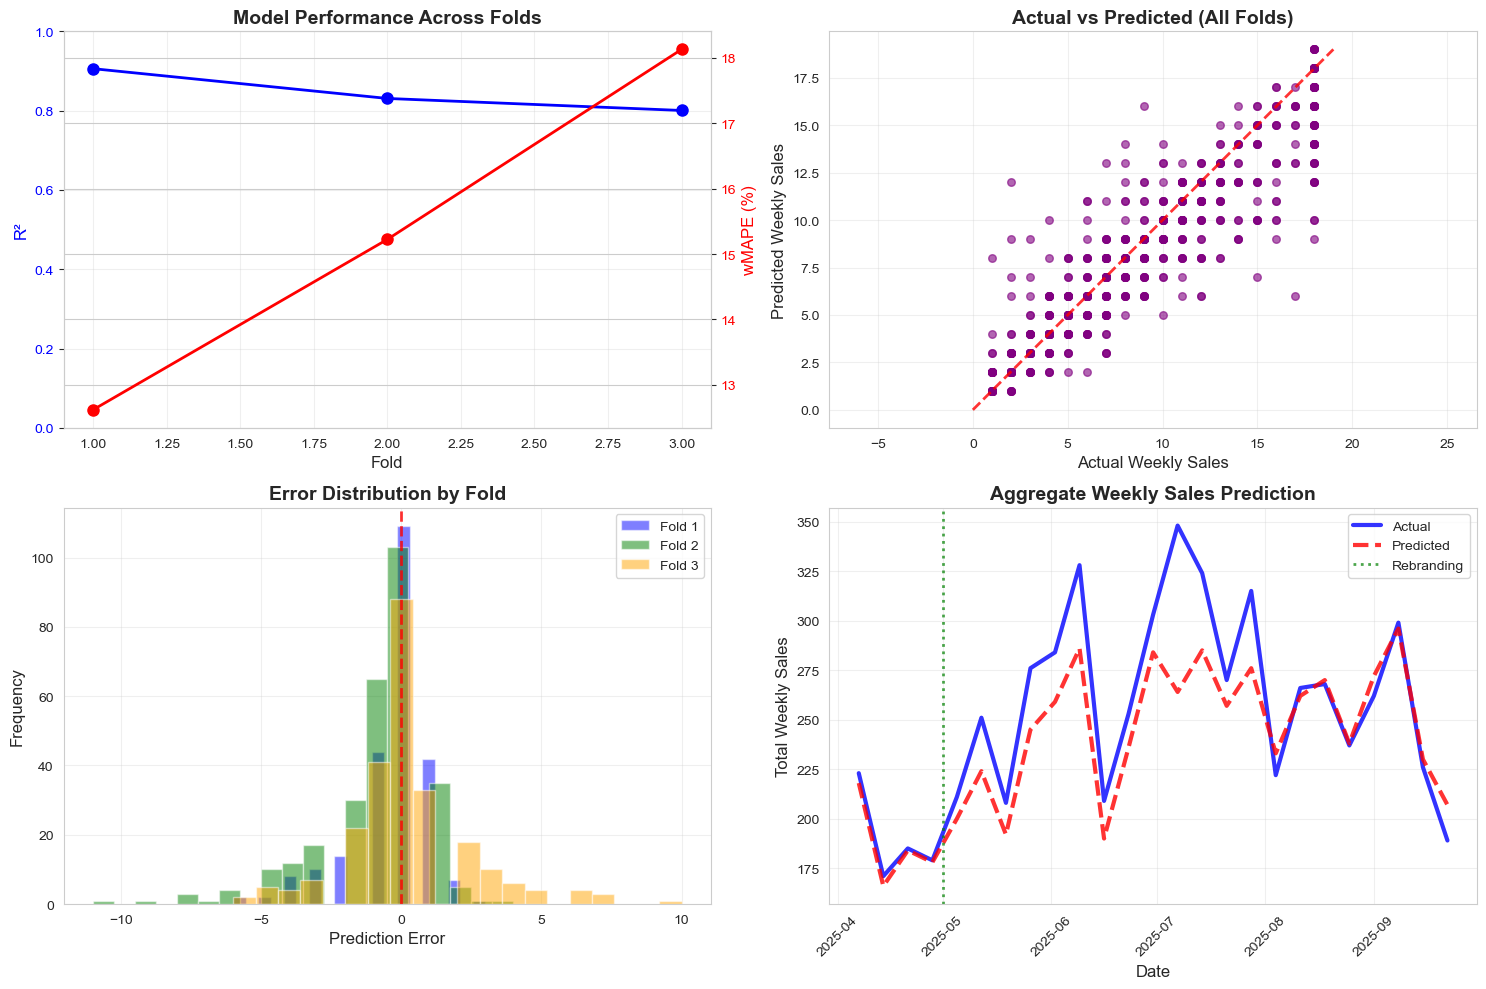

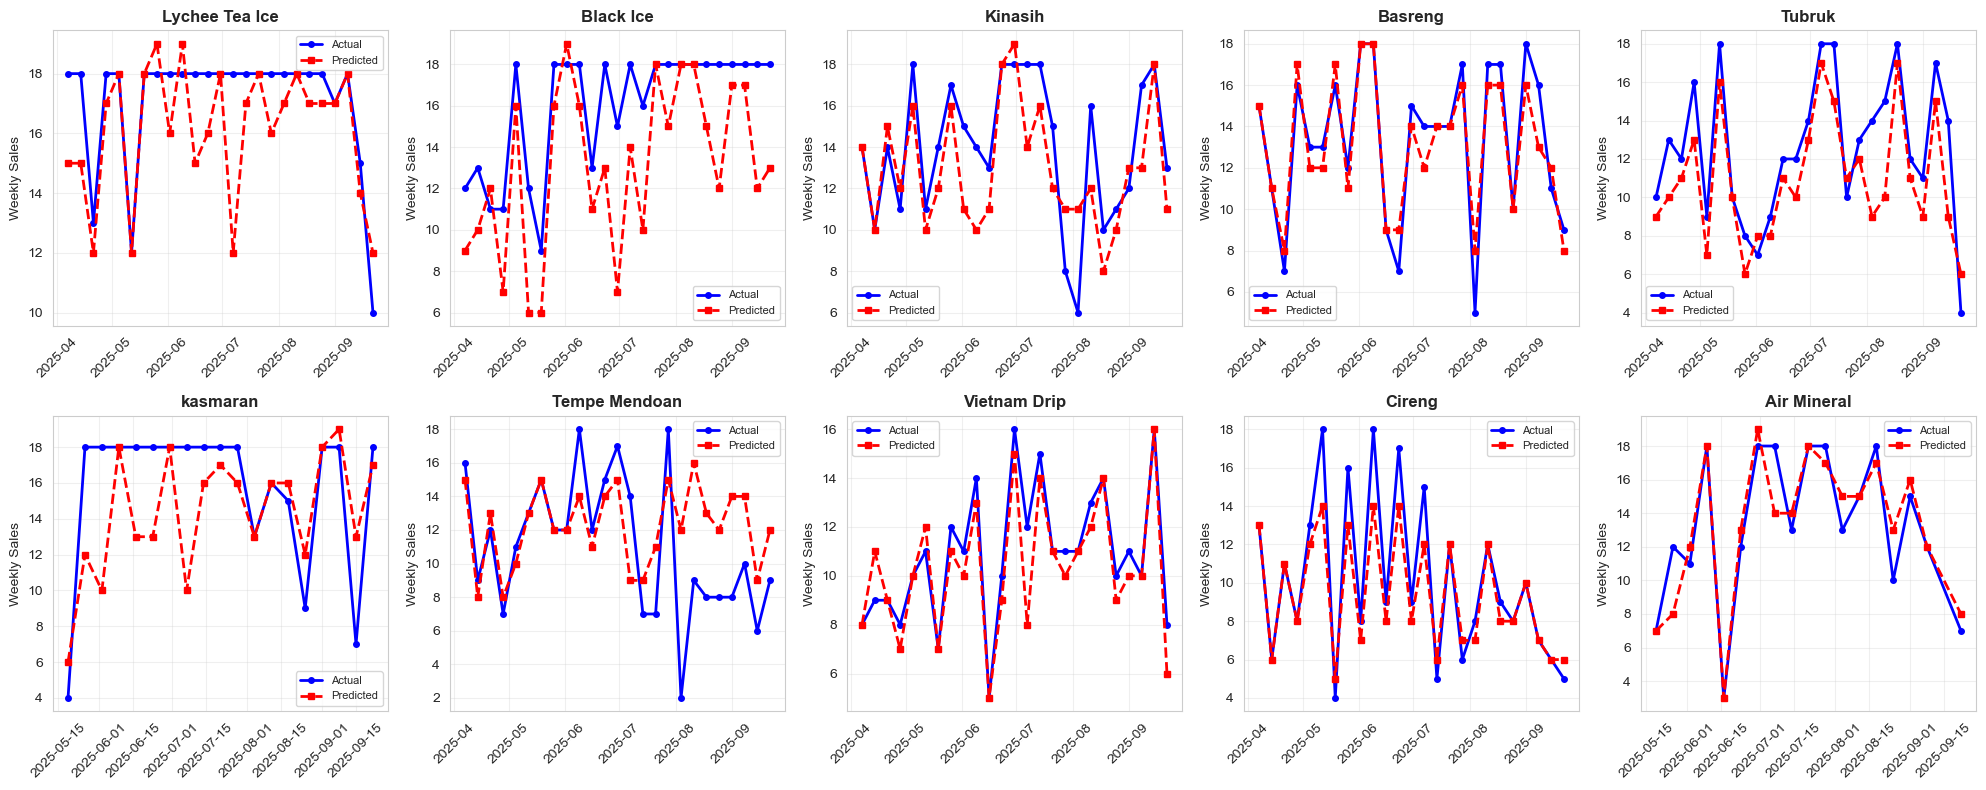


ABC ANALYSIS - WEEKLY MODEL
Global R²        : 0.8459
Global wMAPE     : 15.43%
Global MAE       : 1.25
Total Vol Acc    : 94.37%

ABC BY CLASS
----------------------------------------
A-Class | Items: 15 | wMAPE:  14.7% | Vol.Acc:  94.2%
B-Class | Items:  9 | wMAPE:  17.3% | Vol.Acc:  93.4%
C-Class | Items: 12 | wMAPE:  16.5% | Vol.Acc:  97.2%

TOP 10 CLASS A ITEMS
----------------------------------------
                Quantity_Sold  Predicted  Acc%
Item                                          
Lychee Tea Ice          427.0      403.0  94.4
Black Ice               400.0      327.0  81.8
Kinasih                 349.0      323.0  92.6
Basreng                 332.0      326.0  98.2
Tubruk                  314.0      273.0  86.9
kasmaran                298.0      273.0  91.6
Tempe Mendoan           275.0      306.0  88.7
Vietnam Drip            272.0      258.0  94.9
Cireng                  253.0      234.0  92.5
Air Mineral             238.0      239.0  99.6

WEEKLY ANALYSIS COMPLETE

In [7]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD & AGGREGATE TO WEEKLY
# ==========================================
def load_and_prep_data(filepath):
    print(f"Loading data from: {filepath}")
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[~df['Item'].str.strip().str.lower().str.startswith('add')]
    df_weekly = df.set_index('Date').groupby('Item').resample('W-MON')['Quantity_Sold'].sum().reset_index()
    # Remove weeks with zero sales (might cause issues)
    df_weekly = df_weekly[df_weekly['Quantity_Sold'] > 0]
    return df_weekly

# ==========================================
# 2. CALENDAR & REBRANDING FEATURES
# ==========================================
def add_calendar_features(df):
    data = df.copy()
    data = data.sort_values('Date').reset_index(drop=True)

    data['Month'] = data['Date'].dt.month
    data['Week'] = data['Date'].dt.isocalendar().week.astype(int)
    data['Year'] = data['Date'].dt.year
    data['DOY'] = data['Date'].dt.dayofyear
    data['DOW'] = data['Date'].dt.weekday
    data['Quarter'] = data['Date'].dt.quarter
    data['Is_Weekend'] = (data['DOW'] >= 5).astype(int)

    # Seasonality features
    data['Sin_Week'] = np.sin(2 * np.pi * data['Week'] / 52)
    data['Cos_Week'] = np.cos(2 * np.pi * data['Week'] / 52)
    data['Sin_Month'] = np.sin(2 * np.pi * data['Month'] / 12)
    data['Cos_Month'] = np.cos(2 * np.pi * data['Month'] / 12)
    
    # Trend
    data['Weeks_Since_Start'] = (data['Date'] - data['Date'].min()).dt.days // 7
    data['Day_Of_Month'] = data['Date'].dt.day

    # Payday features
    data['Is_Payday_Week'] = data['Date'].dt.day.apply(lambda x: 1 if x <= 7 or x >= 25 else 0)
    data['Is_Weekend_Before_Payday'] = ((data['DOW'] >= 4) & (data['Date'].dt.day >= 25)).astype(int)

    # Holiday features
    holidays = [
        '2024-01-01','2024-04-10','2024-04-11','2024-04-12','2024-05-01','2024-05-23',
        '2024-06-01','2024-06-17','2024-12-25',
        '2025-01-01','2025-03-01','2025-03-30','2025-03-31','2025-05-01','2025-05-12',
        '2025-06-01','2025-06-07','2025-12-25',
        '2026-01-01','2026-02-17','2026-03-09','2026-05-01','2026-05-21','2026-12-25'
    ]
    data['Is_Holiday'] = data['Date'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)
    data['Is_Near_Holiday'] = data['Date'].apply(
        lambda x: any(abs((x - pd.to_datetime(h)).days) <= 3 for h in holidays)
    ).astype(int)

    # Ramadan
    data['Is_Ramadan'] = 0
    for year in [2024, 2025, 2026]:
        mask = (data['Date'] >= f'{year}-02-28') & (data['Date'] <= f'{year}-04-10')
        data.loc[mask, 'Is_Ramadan'] = 1

    # Rebranding
    data['Is_Post_Rebranding'] = (data['Date'] >= '2025-05-01').astype(int)
    data['Weeks_Since_Rebrand'] = ((data['Date'] - pd.to_datetime('2025-05-01')).dt.days / 7).clip(lower=0)

    return data

# ==========================================
# 3. FEATURE ENGINEERING (WEEKLY)
# ==========================================
def create_features(df):
    data = add_calendar_features(df)
    data = data.sort_values(['Item', 'Date'])
    data['Item_Code'] = data['Item'].astype('category').cat.codes

    for item in data['Item'].unique():
        mask = data['Item'] == item
        g = data.loc[mask, 'Quantity_Sold']

        # Weekly lags
        data.loc[mask, 'Lag_1'] = g.shift(1)
        data.loc[mask, 'Lag_2'] = g.shift(2)
        data.loc[mask, 'Lag_4'] = g.shift(4)
        data.loc[mask, 'Lag_8'] = g.shift(8)

        # Rolling statistics (weekly)
        shifted = g.shift(1)
        data.loc[mask, 'Roll_Mean_4']  = shifted.rolling(4, min_periods=1).mean()
        data.loc[mask, 'Roll_Mean_8']  = shifted.rolling(8, min_periods=1).mean()
        data.loc[mask, 'Roll_Mean_12'] = shifted.rolling(12, min_periods=1).mean()
        data.loc[mask, 'Roll_Std_4']   = shifted.rolling(4, min_periods=1).std().fillna(0)
        data.loc[mask, 'Roll_Std_8']   = shifted.rolling(8, min_periods=1).std().fillna(0)

        # EWMA
        data.loc[mask, 'EWMA_4']  = shifted.ewm(span=4, adjust=False).mean()
        data.loc[mask, 'EWMA_8']  = shifted.ewm(span=8, adjust=False).mean()

        # Momentum
        data.loc[mask, 'Diff_1']  = g.diff(1)
        data.loc[mask, 'Diff_4']  = g.diff(4)

        # Recent vs older trend
        recent = shifted.rolling(4).mean()
        older  = g.shift(5).rolling(8).mean()
        data.loc[mask, 'Recent_vs_Old_Trend'] = (recent / (older + 1)).clip(0, 5)

        # Black Ice handling (weekly version)
        if item == 'Black Ice':
            pre_mask = data.loc[mask, 'Date'] < '2025-05-01'
            post_mask = data.loc[mask, 'Date'] >= '2025-05-01'
            
            if pre_mask.any() and post_mask.any():
                pre_mean = data.loc[mask & pre_mask, 'Quantity_Sold'].mean()
                post_mean = data.loc[mask & post_mask, 'Quantity_Sold'].mean()
                
                surge_factor = min(post_mean / (pre_mean + 1), 3.0)  # Conservative
                
                weeks_since = data.loc[mask & post_mask, 'Weeks_Since_Rebrand']
                decay_factor = np.maximum(0.3, 1 - weeks_since / 20)  # Linear decay to 30%
                
                data.loc[mask & post_mask, 'Black_Ice_Surge'] = surge_factor * decay_factor
                data.loc[mask & pre_mask, 'Black_Ice_Surge'] = 1.0
            else:
                data.loc[mask, 'Black_Ice_Surge'] = 1.0
        else:
            data.loc[mask, 'Black_Ice_Surge'] = 1.0

        # Rebranding effect for other items
        pre_mean  = g[data.loc[mask, 'Date'] < '2025-05-01'].mean()
        post_mean = g[data.loc[mask, 'Date'] >= '2025-05-01'].mean()
        surge = min(post_mean / (pre_mean + 1), 2.0) if pd.notna(post_mean) else 1.0  # Conservative
        data.loc[mask, 'Rebrand_Surge'] = surge

    # Interaction features
    data['Payday_Weekend'] = data['Is_Payday_Week'] * data['Is_Weekend']
    data['Holiday_Weekend'] = data['Is_Holiday'] * data['Is_Weekend']
    
    data = data.fillna(0)
    data.replace([np.inf, -np.inf], 0, inplace=True)
    
    # Conservative clipping
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col not in ['Date', 'Item_Code']:
            data[col] = data[col].clip(
                lower=data[col].quantile(0.05),
                upper=data[col].quantile(0.95)
            )
    
    return data

# ==========================================
# 4. ROBUST TRAINING WITH CROSS-VALIDATION (WEEKLY)
# ==========================================
def train_with_cv_weekly(df_features):
    # Use multiple test periods for weekly data
    test_periods = [
        ('2025-04-01', '2025-05-31'),  # 8 weeks
        ('2025-06-01', '2025-07-31'),  # 8 weeks
        ('2025-08-01', '2025-09-25'),  # 8 weeks
    ]
    
    all_predictions = []
    cv_scores = []
    
    features = [
        'Item_Code','Month','Week','Year','DOY','DOW','Quarter','Is_Weekend','Sin_Week','Cos_Week',
        'Sin_Month','Cos_Month','Weeks_Since_Start','Day_Of_Month','Is_Payday_Week',
        'Is_Weekend_Before_Payday','Is_Holiday','Is_Near_Holiday','Is_Ramadan',
        'Is_Post_Rebranding','Weeks_Since_Rebrand','Black_Ice_Surge','Rebrand_Surge',
        'Recent_vs_Old_Trend','Lag_1','Lag_2','Lag_4','Lag_8','Roll_Mean_4','Roll_Mean_8',
        'Roll_Mean_12','Roll_Std_4','Roll_Std_8','EWMA_4','EWMA_8','Diff_1','Diff_4',
        'Payday_Weekend','Holiday_Weekend'
    ]
    
    for i, (test_start, test_end) in enumerate(test_periods):
        print(f"\n{'='*50}")
        print(f"FOLD {i+1}: Testing {test_start} to {test_end}")
        print(f"{'='*50}")
        
        train = df_features[df_features['Date'] < test_start].copy()
        test  = df_features[(df_features['Date'] >= test_start) & (df_features['Date'] <= test_end)].copy()
        
        print(f"Training: {train['Date'].min().date()} → {train['Date'].max().date()} ({len(train)} weeks)")
        print(f"Testing : {test['Date'].min().date()} → {test['Date'].max().date()} ({len(test)} weeks)")
        
        # Check for NaN values in training data
        train_nan_count = train[features].isnull().sum().sum()
        test_nan_count = test[features].isnull().sum().sum()
        print(f"NaN values - Train: {train_nan_count}, Test: {test_nan_count}")
        
        # Conservative model parameters for weekly data
        global_model = XGBRegressor(
            objective='reg:squarederror',
            n_estimators=500,  # Conservative
            learning_rate=0.1,
            max_depth=4,       # Shallower trees
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            gamma=0.1,
            n_jobs=-1,
            random_state=42
        )
        
        # Ensure no NaN in training features
        train_clean = train.dropna(subset=features)
        global_model.fit(train_clean[features], train_clean['Quantity_Sold'])
        
        fold_predictions = []
        for item in test['Item'].unique():
            train_item = train[train['Item'] == item]
            test_item  = test[test['Item'] == item].copy()

            if len(train_item) >= 20:  # Minimum 20 weeks of data
                # Clean training data for this item
                train_item_clean = train_item.dropna(subset=features)
                
                if len(train_item_clean) > 0:
                    model = XGBRegressor(
                        objective='reg:squarederror',
                        n_estimators=500,
                        learning_rate=0.1,
                        max_depth=4,
                        subsample=0.8,
                        colsample_bytree=0.8,
                        min_child_weight=5,
                        gamma=0.1,
                        n_jobs=-1,
                        random_state=42
                    )
                    
                    model.fit(train_item_clean[features], train_item_clean['Quantity_Sold'], verbose=False)
                    pred = model.predict(test_item[features])
                else:
                    pred = global_model.predict(test_item[features])
            else:
                pred = global_model.predict(test_item[features])

            # Handle NaN predictions
            pred = np.nan_to_num(pred, nan=0.0, posinf=0.0, neginf=0.0)
            
            # Conservative bounds
            max_historical = train_item['Quantity_Sold'].max() if len(train_item) > 0 else 100
            pred = np.maximum(0, pred)
            pred = np.minimum(pred, max_historical * 2)
            
            test_item['Predicted'] = pred.round(0)
            test_item['Fold'] = i + 1
            fold_predictions.append(test_item)
        
        fold_results = pd.concat(fold_predictions)
        
        # Remove any rows with NaN in target or prediction
        fold_results = fold_results.dropna(subset=['Quantity_Sold', 'Predicted'])
        
        # Ensure no zero or negative values in denominator
        valid_mask = (fold_results['Quantity_Sold'] > 0) & (fold_results['Predicted'] >= 0)
        fold_results = fold_results[valid_mask]
        
        print(f"Valid predictions after cleaning: {len(fold_results)} rows")
        
        # Calculate fold metrics with error handling
        if len(fold_results) > 0:
            try:
                fold_r2 = r2_score(fold_results['Quantity_Sold'], fold_results['Predicted'])
                fold_wmape = 100 * abs(fold_results['Quantity_Sold'] - fold_results['Predicted']).sum() / fold_results['Quantity_Sold'].sum()
                fold_mae = mean_absolute_error(fold_results['Quantity_Sold'], fold_results['Predicted'])
            except Exception as e:
                print(f"Error calculating metrics: {e}")
                fold_r2 = 0.0
                fold_wmape = 999.0
                fold_mae = 999.0
        else:
            print("No valid predictions for this fold!")
            fold_r2 = 0.0
            fold_wmape = 999.0
            fold_mae = 999.0
        
        cv_scores.append({
            'fold': i + 1,
            'r2': fold_r2,
            'wmape': fold_wmape,
            'mae': fold_mae,
            'test_weeks': len(test),
            'valid_predictions': len(fold_results)
        })
        
        print(f"Fold {i+1} Results:")
        print(f"  R²: {fold_r2:.4f}")
        print(f"  wMAPE: {fold_wmape:.2f}%")
        print(f"  MAE: {fold_mae:.2f}")
        
        all_predictions.append(fold_results)
    
    # Combine all predictions
    if all_predictions:
        final_predictions = pd.concat(all_predictions).sort_values(['Item', 'Date'])
    else:
        final_predictions = pd.DataFrame()
    
    # Print CV summary
    print(f"\n{'='*50}")
    print("CROSS-VALIDATION SUMMARY")
    print(f"{'='*50}")
    
    cv_df = pd.DataFrame(cv_scores)
    print(cv_df)
    
    if len(cv_df) > 0 and cv_df['r2'].mean() > 0:
        print(f"\nAverage Performance Across Folds:")
        print(f"  R²: {cv_df['r2'].mean():.4f} ± {cv_df['r2'].std():.4f}")
        print(f"  wMAPE: {cv_df['wmape'].mean():.2f}% ± {cv_df['wmape'].std():.2f}%")
        print(f"  MAE: {cv_df['mae'].mean():.2f} ± {cv_df['mae'].std():.2f}")
    
    return final_predictions, cv_df

# ==========================================
# 5. OVERFITTING DIAGNOSTICS
# ==========================================
def check_overfitting(cv_scores):
    print(f"\n{'='*50}")
    print("OVERFITTING DIAGNOSTICS")
    print(f"{'='*50}")
    
    cv_df = pd.DataFrame(cv_scores)
    
    # Check variance in performance
    r2_var = cv_df['r2'].var()
    wmape_var = cv_df['wmape'].var()
    
    print(f"Performance Variance Across Folds:")
    print(f"  R² Variance: {r2_var:.6f}")
    print(f"  wMAPE Variance: {wmape_var:.2f}")
    
    if r2_var > 0.01 or wmape_var > 5:
        print("⚠️  HIGH VARIANCE DETECTED - Model may be overfitting!")
    else:
        print("✅ Stable performance across folds")
    
    # Check for degradation
    r2_trend = cv_df['r2'].iloc[-1] - cv_df['r2'].iloc[0]
    wmape_trend = cv_df['wmape'].iloc[-1] - cv_df['wmape'].iloc[0]
    
    print(f"\nPerformance Trend (Last - First Fold):")
    print(f"  R² Change: {r2_trend:+.4f}")
    print(f"  wMAPE Change: {wmape_trend:+.2f}%")
    
    if r2_trend < -0.05 or wmape_trend > 2:
        print("⚠️  PERFORMANCE DEGRADATION - Model may not generalize well!")
    else:
        print("✅ Consistent performance over time")

# ==========================================
# 6. WEEKLY VISUALIZATION
# ==========================================
def visualize_weekly_cv(predictions, cv_scores):
    if predictions.empty:
        print("No valid predictions to visualize!")
        return
        
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Performance across folds
    cv_df = pd.DataFrame(cv_scores)
    ax1 = axes[0, 0]
    ax1.plot(cv_df['fold'], cv_df['r2'], 'bo-', label='R²', linewidth=2, markersize=8)
    ax1.set_xlabel('Fold', fontsize=12)
    ax1.set_ylabel('R²', color='b', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_title('Model Performance Across Folds', fontweight='bold', fontsize=14)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.0)
    
    ax1_twin = ax1.twinx()
    ax1_twin.plot(cv_df['fold'], cv_df['wmape'], 'ro-', label='wMAPE', linewidth=2, markersize=8)
    ax1_twin.set_ylabel('wMAPE (%)', color='r', fontsize=12)
    ax1_twin.tick_params(axis='y', labelcolor='r')
    
    # 2. Prediction vs Actual (all folds)
    ax2 = axes[0, 1]
    ax2.scatter(predictions['Quantity_Sold'], predictions['Predicted'], alpha=0.6, s=30, color='purple')
    max_val = max(predictions['Quantity_Sold'].max(), predictions['Predicted'].max())
    ax2.plot([0, max_val], [0, max_val], 'r--', alpha=0.8, linewidth=2)
    ax2.set_xlabel('Actual Weekly Sales', fontsize=12)
    ax2.set_ylabel('Predicted Weekly Sales', fontsize=12)
    ax2.set_title('Actual vs Predicted (All Folds)', fontweight='bold', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    
    # 3. Error distribution by fold
    ax3 = axes[1, 0]
    colors = ['blue', 'green', 'orange']
    for i, fold in enumerate(predictions['Fold'].unique()):
        fold_data = predictions[predictions['Fold'] == fold]
        errors = fold_data['Predicted'] - fold_data['Quantity_Sold']
        ax3.hist(errors, bins=20, alpha=0.5, label=f'Fold {fold}', color=colors[i])
    ax3.axvline(x=0, color='red', linestyle='--', alpha=0.8, linewidth=2)
    ax3.set_xlabel('Prediction Error', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Error Distribution by Fold', fontweight='bold', fontsize=14)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Time series of weekly predictions
    ax4 = axes[1, 1]
    weekly_agg = predictions.groupby('Date')[['Quantity_Sold', 'Predicted']].sum()
    ax4.plot(weekly_agg.index, weekly_agg['Quantity_Sold'], 'b-', label='Actual', linewidth=3, alpha=0.8)
    ax4.plot(weekly_agg.index, weekly_agg['Predicted'], 'r--', label='Predicted', linewidth=3, alpha=0.8)
    ax4.axvline(x=pd.to_datetime('2025-05-01'), color='green', linestyle=':', alpha=0.7, linewidth=2, label='Rebranding')
    ax4.set_xlabel('Date', fontsize=12)
    ax4.set_ylabel('Total Weekly Sales', fontsize=12)
    ax4.set_title('Aggregate Weekly Sales Prediction', fontweight='bold', fontsize=14)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('weekly_cv_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Additional: Top items performance
    if len(predictions) > 0:
        top_items = predictions.groupby('Item')['Quantity_Sold'].sum().sort_values(ascending=False).head(10).index
        
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.flatten()
        
        for i, item in enumerate(top_items):
            item_data = predictions[predictions['Item'] == item].sort_values('Date')
            
            if len(item_data) > 0:
                axes[i].plot(item_data['Date'], item_data['Quantity_Sold'], 'o-', 
                            color='blue', label='Actual', linewidth=2, markersize=4)
                axes[i].plot(item_data['Date'], item_data['Predicted'], 's--', 
                            color='red', label='Predicted', linewidth=2, markersize=4)
            
            axes[i].set_title(f'{item}', fontweight='bold')
            axes[i].set_ylabel('Weekly Sales')
            axes[i].legend(fontsize=8)
            axes[i].grid(True, alpha=0.3)
            axes[i].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.savefig('weekly_top_items.png', dpi=300, bbox_inches='tight')
        plt.show()

# ==========================================
# 7. RUN WEEKLY MODEL
# ==========================================
if __name__ == "__main__":
    print("LOADING AND PREPARING WEEKLY DATA...")
    df_raw = load_and_prep_data('../data/processed/daily_item_sales.csv')
    print(f"Weekly data shape: {df_raw.shape}")
    print(f"Date range: {df_raw['Date'].min()} to {df_raw['Date'].max()}")
    print(f"Number of items: {df_raw['Item'].nunique()}")
    
    print("\nCREATING WEEKLY FEATURES...")
    df_feat = create_features(df_raw)
    print(f"Features created. Shape: {df_feat.shape}")
    
    print("\nTRAINING WEEKLY MODEL WITH CROSS-VALIDATION...")
    predictions, cv_scores = train_with_cv_weekly(df_feat)
    
    print("\nCHECKING FOR OVERFITTING...")
    check_overfitting(cv_scores)
    
    print("\nGENERATING WEEKLY VISUALIZATIONS...")
    visualize_weekly_cv(predictions, cv_scores)
    
    # ABC Analysis
    if not predictions.empty:
        print("\n" + "="*50)
        print("ABC ANALYSIS - WEEKLY MODEL")
        print("="*50)
        
        y_true = predictions['Quantity_Sold']
        y_pred = predictions['Predicted']
        
        print(f"Global R²        : {r2_score(y_true, y_pred):.4f}")
        print(f"Global wMAPE     : {100 * abs(y_true - y_pred).sum() / y_true.sum():.2f}%")
        print(f"Global MAE       : {mean_absolute_error(y_true, y_pred):.2f}")
        print(f"Total Vol Acc    : {100 * (1 - abs(y_true.sum() - y_pred.sum()) / y_true.sum()):.2f}%")
        
        # ABC classification
        item_vol = predictions.groupby('Item')['Quantity_Sold'].sum().sort_values(ascending=False)
        total = item_vol.sum()
        item_vol = pd.DataFrame({'Vol': item_vol,
                               'Cum': item_vol.cumsum(),
                               'Pct': item_vol.cumsum() / total})
        item_vol['Class'] = item_vol['Pct'].apply(lambda x: 'A' if x <= 0.70 else ('B' if x <= 0.90 else 'C'))
        predictions['Class'] = predictions['Item'].map(item_vol['Class'])
        
        print("\nABC BY CLASS")
        print("-"*40)
        for c in ['A', 'B', 'C']:
            sub = predictions[predictions['Class'] == c]
            if len(sub) == 0: continue
            wmape = 100 * abs(sub['Quantity_Sold'] - sub['Predicted']).sum() / sub['Quantity_Sold'].sum()
            volacc = 100 * (1 - abs(sub['Quantity_Sold'].sum() - sub['Predicted'].sum()) / sub['Quantity_Sold'].sum())
            print(f"{c}-Class | Items: {sub['Item'].nunique():2d} | wMAPE: {wmape:5.1f}% | Vol.Acc: {volacc:5.1f}%")
        
        print("\nTOP 10 CLASS A ITEMS")
        print("-"*40)
        top = predictions[predictions['Class'] == 'A'].groupby('Item')[['Quantity_Sold','Predicted']].sum()
        top = top.sort_values('Quantity_Sold', ascending=False).head(10)
        top['Acc%'] = (100 * (1 - abs(top['Predicted'] - top['Quantity_Sold']) / top['Quantity_Sold'])).round(1)
        print(top[['Quantity_Sold','Predicted','Acc%']])
    
    print("\n" + "="*50)
    print("WEEKLY ANALYSIS COMPLETE!")
    print("Generated files:")
    print("- weekly_cv_analysis.png")
    print("- weekly_top_items.png")
    print("="*50)